# Sequential Modeling and RNNs

## Sequential Data

At its simplest, sequential data is just a list of items arranged in order. It is inherently ordered, meaning that the position of each element matters. Whether you're forecasting the weather or predicting stock market trends, understanding how each element in the sequence relates to its predecessors is key. The challenge lies in capturing the relationships between these items to make accurate predictions.

### Examples of Sequential Data

Consider these real-world applications where sequential data is fundamental:

- **Weather Forecasting:** Predicting future conditions based on historical weather patterns.
- **Stock Market Trends:** Analyzing time series data of stock prices.
- **Autocomplete for Text:** Suggesting the next word or phrase while you type.
- **Genetic Sequencing:** Interpreting the order of nucleotides in DNA.
- **Speech Recognition:** Transcribing spoken language by understanding sequential audio signals.
- **Video Frame Prediction:** Forecasting the next frame in a video sequence.
- **Music Composition:** Generating sequences of musical notes that form a coherent melody.


### Two Main Goals with Sequential Data

1. **Computing the Probability of a Sequence:**  
   The goal is to determine the likelihood that a particular sequence of events or items occurs. This involves calculating the probability of each element in the context of those that came before it.

2. **Predicting the Next Item in a Sequence:**  
   Given a history of previous items, we want to forecast what the next item will be. This is critical for tasks like text autocomplete or predicting market trends.

![](https://upload.wikimedia.org/wikipedia/commons/a/a7/Random_vs_sequential_access.svg)

## Reviewing Probability Concepts


### Conditional Probability

Conditional probability is all about context - it tells us the probability of an event occurring given that another event has already happened. Mathematically, if we have two events $A$ and $B$, the conditional probability of $B$ given $A$ is defined as:

$$
P(B \mid A) = \frac{P(A, B)}{P(A)}
$$

This formula assumes that $P(A)$ is not zero. It tells us how likely $B$ is to occur when we already know that $A$ has occurred. In sequential data, this means that the probability of seeing a certain word, for example, may depend on the words that came before it.


### The Chain Rule

The chain rule of probability is a tool that allows us to break down the probability of a long sequence into a product of conditional probabilities. Suppose you have a sequence of items $x_1, x_2, \dots, x_n$. The chain rule states that the joint probability of the entire sequence can be expressed as:

$$
P(x_1, x_2, \dots, x_n) = P(x_1) \times P(x_2 \mid x_1) \times P(x_3 \mid x_1, x_2) \times \cdots \times P(x_n \mid x_1, x_2, \dots, x_{n-1})
$$

By decomposing a complex joint probability into manageable pieces, we can handle the computation more effectively. 

#### Step-by-Step Explanation

1. **Start Simple:**  
   The first term $P(x_1)$ is the probability of the first item in the sequence. There’s no history, so it stands alone.

2. **Build Context:**  
   For the second item, $P(x_2 \mid x_1)$ tells us the probability of $x_2$ occurring after $x_1$. It captures how $x_1$ influences $x_2$.

3. **Continuing the Sequence:**  
   For the third item, $P(x_3 \mid x_1, x_2)$ incorporates the context of both previous items, and so on. Each term adds more context, making the overall model richer.


### Challenges

While the chain rule provides a clean theoretical framework, real-world applications often run into two major issues:

1. **Computational Complexity:**
   - **Too Many Parameters:**  
     With longer sequences, the number of possible combinations of previous items becomes enormous. This leads to a combinatorial explosion in the number of conditional probabilities that need to be estimated, making it computationally expensive or even infeasible to model every possible sequence.

2. **Generalization to Unseen Data:**
   - **Data Sparsity:**  
     Since it’s impractical to encounter every possible sequence during training, models often face situations where they must predict probabilities for sequences or elements they have never seen before.
   - **Zero-Probability Problem:**  
     If a sequence or a particular context has not been observed during training, the model might erroneously assign it a probability of zero, even though the sequence could be perfectly plausible.


## Markov Models

Markov Models are one of the earliest and simplest approaches to modeling sequential data. They are built on a key assumption: the **Markov Assumption**.

### The Markov Assumption

At its core, the Markov Assumption states that the future state depends only on a limited part of the past. In other words, once you know the present (or a limited number of previous states), you don't need the entire history to predict the future. This assumption simplifies the modeling process by limiting the context window we need to consider when predicting the next item.

This idea can be expressed mathematically:

- For a **First Order Markov Model**:

$$
P(x_t \mid x_1, x_2, \dots, x_{t-1}) \approx P(x_t \mid x_{t-1})
$$

- For a **Second Order Markov Model**:

$$
P(x_t \mid x_1, x_2, \dots, x_{t-1}) \approx P(x_t \mid x_{t-2}, x_{t-1})
$$


### First Order Markov Model

In a first order Markov model, the current state depends solely on the immediately preceding state. For example, when modeling weather, one might assume that tomorrow's weather depends only on today's weather, not on the weather of days before today.

#### The Transition Matrix — the heart of the model

Everything a first-order Markov model "knows" lives in one place: the **transition matrix**. It is just a table of probabilities that answers a single question — *"given today's weather, what is the probability of each possible weather tomorrow?"*

Suppose the weather can only be **Sunny**, **Cloudy**, or **Rainy**. The transition matrix looks like this:

| Today ↓ \ Tomorrow → | Sunny | Cloudy | Rainy |
|---|---|---|---|
| **Sunny**  | 0.7 | 0.2 | 0.1 |
| **Cloudy** | 0.3 | 0.4 | 0.3 |
| **Rainy**  | 0.2 | 0.3 | 0.5 |

How to read it:

- **Each row is "today."** Pick the row for the current weather.
- **Each column is "tomorrow."** The numbers in that row are the probabilities of each possible next day.
- **Every row sums to 1.0**, because tomorrow has to be *something*.

So the top row says: *if today is Sunny, there's a 70% chance tomorrow is Sunny, 20% Cloudy, and 10% Rainy.* That single row **is** the conditional distribution $P(\text{tomorrow} \mid \text{today} = \text{Sunny})$.

In the code below we (1) build this exact matrix, (2) **display it as a table so you can see it**, (3) read one row as a worked example, and (4) use it to simulate a realistic weather sequence.

#### Example

In [35]:
import random
import pandas as pd
from collections import Counter

# The three weather conditions our model can be in ("states").
states = ["Sunny", "Cloudy", "Rainy"]

# ---------------------------------------------------------------------------
# STEP 1: Define the transition matrix  ->  P(tomorrow | today)
# Read it row by row: each ROW is TODAY's weather, each COLUMN gives the
# probability of TOMORROW's weather. Every row must sum to 1.0.
# ---------------------------------------------------------------------------
transition_matrix = {
    "Sunny":  {"Sunny": 0.7, "Cloudy": 0.2, "Rainy": 0.1},
    "Cloudy": {"Sunny": 0.3, "Cloudy": 0.4, "Rainy": 0.3},
    "Rainy":  {"Sunny": 0.2, "Cloudy": 0.3, "Rainy": 0.5},
}

# Let's actually LOOK at the matrix as a table (rows = today, cols = tomorrow).
matrix_df = pd.DataFrame(transition_matrix).T   # .T puts "today" on the rows
matrix_df.index.name = "Today"
print("Transition matrix  ->  P(tomorrow | today):")
display(matrix_df)
print("Row sums (each should be 1.0):", matrix_df.sum(axis=1).to_dict())

# Worked example: just read one row of the matrix.
print("\nIf today is 'Sunny', the model says tomorrow will be:")
for tomorrow, p in transition_matrix["Sunny"].items():
    print(f"   {tomorrow:<7} with probability {p:.0%}")

# ---------------------------------------------------------------------------
# STEP 2: Use the matrix to simulate weather.
# At each step we look up TODAY's row and randomly draw TOMORROW
# according to those probabilities.
# ---------------------------------------------------------------------------
def next_state(current_state):
    next_probs = transition_matrix[current_state]
    return random.choices(list(next_probs.keys()), list(next_probs.values()))[0]

random.seed(0)  # makes the example reproducible
current_state = "Sunny"
sequence = [current_state]
for _ in range(14):
    current_state = next_state(current_state)
    sequence.append(current_state)

print("\nSimulated 15-day weather sequence:")
print("  " + " -> ".join(sequence))

# ---------------------------------------------------------------------------
# STEP 3: Sanity check. Over a LONG simulation, how often does each kind of
# day occur? The frequencies reflect the probabilities baked into the matrix.
# ---------------------------------------------------------------------------
long_run = ["Sunny"]
for _ in range(10000):
    long_run.append(next_state(long_run[-1]))
counts = Counter(long_run)
print("\nOver 10,000 simulated days, each type of weather occurred:")
for s in states:
    print(f"   {s:<7} {counts[s] / len(long_run):.1%} of days")

Transition matrix  ->  P(tomorrow | today):


,Sunny,Cloudy,Rainy
Today,,,
Sunny,0.7,0.2,0.1
Cloudy,0.3,0.4,0.3
Rainy,0.2,0.3,0.5


Row sums (each should be 1.0): {'Sunny': 0.9999999999999999, 'Cloudy': 1.0, 'Rainy': 1.0}

If today is 'Sunny', the model says tomorrow will be:
   Sunny   with probability 70%
   Cloudy  with probability 20%
   Rainy   with probability 10%

Simulated 15-day weather sequence:
  Sunny -> Cloudy -> Rainy -> Cloudy -> Sunny -> Sunny -> Sunny -> Cloudy -> Cloudy -> Cloudy -> Cloudy -> Rainy -> Rainy -> Cloudy -> Rainy

Over 10,000 simulated days, each type of weather occurred:
   Sunny   45.2% of days
   Cloudy  28.8% of days
   Rainy   26.0% of days


### Second Order Markov Model

A second order Markov model extends the first order idea by considering the **two** most recent states instead of just one. This gives the model a slightly longer memory. For instance, the weather tomorrow might depend on both today's and yesterday's weather (e.g., two rainy days in a row might make a third rainy day more likely than a single rainy day would).

#### How It Works — and why the matrix gets bigger

The key change is what counts as a "state":

- In the **first order** model, the state was a single day, so the matrix had **3 rows** (Sunny, Cloudy, Rainy).
- In the **second order** model, the state is a **pair** of consecutive days, `(yesterday, today)`. With 3 conditions there are now $3 \times 3 = 9$ possible pairs, so the matrix has **9 rows**, each still giving 3 probabilities for tomorrow.

That means the number of probabilities we must specify jumps from $3 \times 3 = 9$ to $3 \times 3 \times 3 = 27$. This is the central trade-off of Markov models: **each extra step of memory multiplies the size of the table.** A third-order model would need $3^4 = 81$ entries, and a model over a 10,000-word vocabulary would be astronomically large — which is exactly the limitation that motivates RNNs later in this notebook.

The code below builds the 9-row matrix, displays it so you can see the `(yesterday, today)` pairs on the rows, reads one row as a worked example, and simulates a sequence.

#### Example

In [36]:
import random
import pandas as pd

states = ["Sunny", "Cloudy", "Rainy"]

# ---------------------------------------------------------------------------
# In a SECOND-order model the "state" is the last TWO days.
# So each key is a pair (yesterday, today) and the value is the probability
# distribution over tomorrow. With 3 conditions there are 3 x 3 = 9 pairs,
# each needing 3 probabilities  ->  27 numbers total (vs. 9 for first order).
# ---------------------------------------------------------------------------
transition_matrix = {
    ("Sunny",  "Sunny"):  {"Sunny": 0.6, "Cloudy": 0.3, "Rainy": 0.1},
    ("Sunny",  "Cloudy"): {"Sunny": 0.3, "Cloudy": 0.4, "Rainy": 0.3},
    ("Sunny",  "Rainy"):  {"Sunny": 0.2, "Cloudy": 0.3, "Rainy": 0.5},
    ("Cloudy", "Sunny"):  {"Sunny": 0.5, "Cloudy": 0.3, "Rainy": 0.2},
    ("Cloudy", "Cloudy"): {"Sunny": 0.2, "Cloudy": 0.5, "Rainy": 0.3},
    ("Cloudy", "Rainy"):  {"Sunny": 0.1, "Cloudy": 0.3, "Rainy": 0.6},
    ("Rainy",  "Sunny"):  {"Sunny": 0.3, "Cloudy": 0.4, "Rainy": 0.3},
    ("Rainy",  "Cloudy"): {"Sunny": 0.2, "Cloudy": 0.4, "Rainy": 0.4},
    ("Rainy",  "Rainy"):  {"Sunny": 0.1, "Cloudy": 0.3, "Rainy": 0.6},
}

# Visualize it: the rows are now the (yesterday, today) PAIRS, columns = tomorrow.
matrix_df = pd.DataFrame(transition_matrix).T
matrix_df.index = pd.MultiIndex.from_tuples(matrix_df.index, names=["Yesterday", "Today"])
print("Second-order transition matrix  ->  P(tomorrow | yesterday, today):")
display(matrix_df)

# Worked example: read one row.
print("\nIf yesterday was 'Cloudy' and today is 'Rainy', tomorrow will be:")
for tomorrow, p in transition_matrix[("Cloudy", "Rainy")].items():
    print(f"   {tomorrow:<7} with probability {p:.0%}")

# Now look up the last TWO days to draw the next one.
def next_state(prev_state, current_state):
    next_probs = transition_matrix[(prev_state, current_state)]
    return random.choices(list(next_probs.keys()), list(next_probs.values()))[0]

random.seed(0)
sequence = ["Sunny", "Cloudy"]   # need two days to start a second-order model
for _ in range(13):
    sequence.append(next_state(sequence[-2], sequence[-1]))

print("\nSimulated 15-day weather sequence (second order):")
print("  " + " -> ".join(sequence))

Second-order transition matrix  ->  P(tomorrow | yesterday, today):


Sunny  Cloudy  Rainy
Yesterday Today                       
Sunny     Sunny     0.6     0.3    0.1
          Cloudy    0.3     0.4    0.3
          Rainy     0.2     0.3    0.5
Cloudy    Sunny     0.5     0.3    0.2
          Cloudy    0.2     0.5    0.3
          Rainy     0.1     0.3    0.6
Rainy     Sunny     0.3     0.4    0.3
          Cloudy    0.2     0.4    0.4
          Rainy     0.1     0.3    0.6


If yesterday was 'Cloudy' and today is 'Rainy', tomorrow will be:
   Sunny   with probability 10%
   Cloudy  with probability 30%
   Rainy   with probability 60%

Simulated 15-day weather sequence (second order):
  Sunny -> Cloudy -> Rainy -> Rainy -> Rainy -> Cloudy -> Cloudy -> Cloudy -> Rainy -> Cloudy -> Cloudy -> Cloudy -> Rainy -> Rainy -> Cloudy


### Limitations of Markov Models

Despite their simplicity and ease of understanding, Markov models come with several limitations:

- **Finite Context:**  
  Because the model only considers a fixed number of previous states, it is unable to capture long-term dependencies. This finite context might be insufficient for tasks where earlier events have a significant influence on future outcomes.

- **Lack of Memory:**  
  Markov models inherently have no memory beyond their defined order. They cannot retain information about events outside of the fixed context window, such as long-term trends or seasonal effects in data.

- **Stationarity Assumption:**  
  Markov models assume that the transition probabilities remain constant over time. In many real-world situations, the underlying data-generating processes may change, which can reduce the effectiveness of the model if these changes are not taken into account.


## RNNs – Recurrent Neural Networks

Recurrent Neural Networks (RNNs) are a powerful class of neural networks specifically designed to handle sequential data. Unlike traditional feedforward networks that assume each input is independent, RNNs introduce a notion of "memory" through a hidden state that is recursively updated. This allows them to capture information from previous inputs, making them well-suited for tasks where context matters.

![](FNN_RNN.png)

### Residual Neural Networks (ResNets) vs. RNNs (Recurrent Neural Networks)

**Residual Neural Networks (ResNets)** are a type of feedforward convolutional neural network (CNN) architecture, primarily used for image recognition, classification, and other computer vision tasks. What distinguishes ResNets is the introduction of skip connections (or shortcut connections), which allow the network to bypass one or more layers. 
- The skip connections help mitigate the vanishing gradient problem by allowing gradients to flow directly through the network during backpropagation. 
- Instead of learning the full mapping from input to output, each residual block learns a residual function — essentially the difference between the input and the output.
- ResNets enable the training of very deep networks (e.g., with 50, 101, or even 152 layers) without suffering from degradation in performance.

**Recurrent Neural Networks (RNNs)**, on the other hand, are designed for sequential or time-series data such as text, audio, or stock prices. They maintain a hidden state that is passed from one time step to the next, giving them a form of memory and allowing them to capture temporal dependencies.
- Each step of the sequence shares the same weights, enabling the model to process input of variable lengths.
- RNNs suffer from vanishing/exploding gradients over long sequences, which led to the development of improved variants like LSTM (Long Short-Term Memory) and GRU (Gated Recurrent Unit) networks.
- Commonly used in language modeling, speech recognition, and sequence prediction tasks.

### How RNNs Work

At each time step, an RNN takes an input (e.g., a word or a data point) and combines it with its hidden state from the previous time step to produce a new hidden state. This process can be expressed mathematically as:

$$
h_t = f(W_{xh} \, x_t + W_{hh} \, h_{t-1} + b_h)
$$

where:
- $x_t$ is the input at time $t$,
- $h_t$ is the hidden state at time $t$,
- $W_{xh}$ and $W_{hh}$ are weight matrices,
- $b_h$ is a bias term,
- $f$ is an activation function (such as tanh or ReLU).

The key idea is that the hidden state $h_t$ carries information from previous time steps, allowing the network to maintain a form of memory. This recursive update mechanism enables RNNs to handle varying context sizes without needing a fixed-length input.

![](RNN_Representation.png)

### Auto-Regressive Models

RNNs are inherently auto-regressive models. This means that they predict the value at time $t$ based on a function of the previous values (e.g., $t-1$, $t-2$, etc.). In the context of language modeling, the probability of a sequence is modeled as:

$$
P(x_1, x_2, \dots, x_T) = \prod_{t=1}^{T} P(x_t \mid x_1, x_2, \dots, x_{t-1})
$$

The auto-regressive property enables RNNs to generate coherent sequences, as each prediction is conditioned on the sequence generated so far.

### Generating Sequences Using RNNs

One common application of RNNs is sequence generation. For instance, when generating text, an RNN is trained to predict the next word given a sequence of previous words. During generation, the network outputs a probability distribution over the vocabulary at each step, and a word is chosen (often in an auto-regressive manner) to be fed back into the network for the next prediction.

A simplified conceptual flow for generating a sentence is as follows:
1. **Initialization:** Start with a seed word or sequence.
2. **Prediction:** Use the RNN to predict the probability of each possible next word.
3. **Selection:** Pick the next word based on the probability distribution.
4. **Recursion:** Feed the chosen word back into the RNN and repeat until a stopping condition (like a special end-of-sequence token) is reached.

#### Example: learning the days of the week

To make it obvious whether the network *actually learned something*, we'll train it on a pattern you already know by heart: **the days of the week, repeating forever** — `Mon, Tue, Wed, Thu, Fri, Sat, Sun, Mon, Tue, ...`

The rule is simple ("after Friday comes Saturday"), so when we later seed the model with a few days and let it generate, we can immediately tell whether it learned the cycle — the output will be real day names in the right order, not meaningless numbers. We use a tiny vocabulary of 7 tokens (the 7 days) so the model trains in seconds and reaches near-100% accuracy.

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# ---------------------------------------------------------------------------
# A learnable toy sequence: the days of the week, repeating forever.
# Because the pattern is obvious to us, it's easy to SEE whether the RNN
# learned it (the generated output should be real day names in order).
#
# NOTE: we use a 3-day window, which is SHORTER than the 7-day cycle. That
# matters! If the window equaled the cycle length (7), the model could "cheat"
# by copying the first day of the window instead of learning the real
# "next = today + 1" rule. A shorter window forces it to learn the true pattern.
# ---------------------------------------------------------------------------
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
vocab_size = len(days)      # 7 possible tokens
embedding_dim = 8
rnn_units = 32
sequence_length = 3         # look back 3 days to predict the next day

# Build a long stream of day-indices: 0,1,2,3,4,5,6,0,1,2,...  (52 weeks)
stream = np.array([i % 7 for i in range(7 * 52)])

# Turn the stream into (input window -> next day) supervised training pairs.
def make_windows(stream, sequence_length):
    X, y = [], []
    for i in range(len(stream) - sequence_length):
        X.append(stream[i:i + sequence_length])
        y.append(stream[i + sequence_length])
    return np.array(X), np.array(y)

input_sequences, target_days = make_windows(stream, sequence_length)

# Build a simple RNN model
model = Sequential([
    Embedding(vocab_size, embedding_dim),
    SimpleRNN(rnn_units),
    Dense(vocab_size, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(input_sequences, target_days, epochs=30, batch_size=16, verbose=0)
print(f"Final training accuracy: {model.evaluate(input_sequences, target_days, verbose=0)[1]:.0%}")

# Auto-Regressive Generation: feed each prediction back in as the next input.
def generate_days(model, seed_days, num_predictions):
    generated = [days.index(d) for d in seed_days]
    for _ in range(num_predictions):
        window = np.array(generated[-sequence_length:]).reshape(1, -1)
        next_idx = int(np.argmax(model.predict(window, verbose=0)[0]))
        generated.append(next_idx)
    return [days[i] for i in generated]

seed = ["Mon", "Tue", "Wed"]
result = generate_days(model, seed, num_predictions=10)
print("Seed:     ", " -> ".join(seed))
print("Generated:", " -> ".join(result))

Final training accuracy: 100%
Seed:      Mon -> Tue -> Wed
Generated: Mon -> Tue -> Wed -> Thu -> Fri -> Sat -> Sun -> Mon -> Tue -> Wed -> Thu -> Fri -> Sat


### Stacked RNNs

For more complex tasks, a single RNN layer might not capture all the nuances of the data. **Stacked RNNs** address this by employing multiple layers of RNNs. In a stacked RNN, the hidden states produced by one layer become the inputs for the next layer. This allows the network to learn hierarchical representations of the data:
- **Lower layers** may capture local, short-term dependencies.
- **Higher layers** may capture more abstract, long-term patterns.

Stacking layers can greatly enhance the model's ability to understand complex sequential patterns, though it requires more computational resources and can make training more challenging.

#### Example

We'll reuse the same days-of-the-week task so you can compare architectures directly. The only change is that we stack **two** `SimpleRNN` layers. The first layer uses `return_sequences=True` so it passes its full sequence of hidden states up to the second layer.

In [38]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Same repeating days-of-the-week task as before (3-day window < 7-day cycle).
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
vocab_size, sequence_length = len(days), 3
stream = np.array([i % 7 for i in range(7 * 52)])
X, y = [], []
for i in range(len(stream) - sequence_length):
    X.append(stream[i:i + sequence_length]); y.append(stream[i + sequence_length])
X, y = np.array(X), np.array(y)

# Two stacked RNN layers. The first returns its full sequence of hidden states
# (return_sequences=True) so the second RNN can read it as an input sequence.
stacked_model = Sequential([
    Embedding(vocab_size, 8),
    SimpleRNN(32, return_sequences=True),   # outputs a value at every time step
    SimpleRNN(32),                          # reads that sequence, outputs the last state
    Dense(vocab_size, activation='softmax')
])
stacked_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
stacked_model.fit(X, y, epochs=30, batch_size=16, verbose=0)
print(f"Final training accuracy: {stacked_model.evaluate(X, y, verbose=0)[1]:.0%}")

def generate_days(model, seed_days, num_predictions):
    generated = [days.index(d) for d in seed_days]
    for _ in range(num_predictions):
        window = np.array(generated[-sequence_length:]).reshape(1, -1)
        generated.append(int(np.argmax(model.predict(window, verbose=0)[0])))
    return [days[i] for i in generated]

seed = ["Fri", "Sat", "Sun"]
result = generate_days(stacked_model, seed, num_predictions=10)
print("Seed:     ", " -> ".join(seed))
print("Generated:", " -> ".join(result))

Final training accuracy: 100%
Seed:      Fri -> Sat -> Sun
Generated: Fri -> Sat -> Sun -> Mon -> Tue -> Wed -> Thu -> Fri -> Sat -> Sun -> Mon -> Tue -> Wed


## Other Options: LSTM and GRU

Standard RNNs can struggle with learning long-term dependencies due to issues like vanishing and exploding gradients. Two popular alternatives have been developed to address these challenges:

- **LSTM (Long Short-Term Memory):**  
  LSTMs introduce gating mechanisms (input, forget, and output gates) that allow the network to control the flow of information and maintain long-term dependencies more effectively.

- **GRU (Gated Recurrent Unit):**  
  GRUs are a simplified version of LSTMs that combine the forget and input gates into a single update gate. They are often faster to train and can perform comparably well on many tasks.



### LSTM Example

LSTM (Long Short-Term Memory) networks are a variant of RNNs designed to overcome the vanishing gradient problem and better capture long-term dependencies. They use gating mechanisms (input, forget, and output gates) to control the flow of information.

We'll run the **same days-of-the-week task** one more time, swapping the `SimpleRNN` layer for an `LSTM` layer. On this easy pattern the LSTM also reaches ~100% accuracy — the real advantage of LSTMs shows up on long, complex sequences like the Shakespeare text further down.

In [39]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Same repeating days-of-the-week task, now with an LSTM layer.
# (3-day window < 7-day cycle, so the model must learn the real "+1" rule.)
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
vocab_size, sequence_length = len(days), 3
stream = np.array([i % 7 for i in range(7 * 52)])
X, y = [], []
for i in range(len(stream) - sequence_length):
    X.append(stream[i:i + sequence_length]); y.append(stream[i + sequence_length])
X, y = np.array(X), np.array(y)

# Build a simple LSTM model (just swap SimpleRNN -> LSTM)
lstm_model = Sequential([
    Embedding(vocab_size, 8),
    LSTM(32),
    Dense(vocab_size, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X, y, epochs=30, batch_size=16, verbose=0)
print(f"Final training accuracy: {lstm_model.evaluate(X, y, verbose=0)[1]:.0%}")

def generate_days(model, seed_days, num_predictions):
    generated = [days.index(d) for d in seed_days]
    for _ in range(num_predictions):
        window = np.array(generated[-sequence_length:]).reshape(1, -1)
        generated.append(int(np.argmax(model.predict(window, verbose=0)[0])))
    return [days[i] for i in generated]

seed = ["Wed", "Thu", "Fri"]
result = generate_days(lstm_model, seed, num_predictions=10)
print("Seed:     ", " -> ".join(seed))
print("Generated:", " -> ".join(result))

Final training accuracy: 100%
Seed:      Wed -> Thu -> Fri
Generated: Wed -> Thu -> Fri -> Sat -> Sun -> Mon -> Tue -> Wed -> Thu -> Fri -> Sat -> Sun -> Mon


### Comparison

**Basic RNN vs. LSTM:**  
Both models work in an auto-regressive fashion to generate sequences. However, LSTM networks include internal gating mechanisms that allow them to better remember information over longer sequences. This means that while a simple RNN may struggle with longer context due to vanishing gradients, an LSTM is more robust in capturing long-term dependencies.

**Model Complexity:**  
LSTM units are more complex than SimpleRNN cells because they maintain additional parameters (gates) to control memory. This typically results in better performance on tasks requiring long-term context, at the cost of increased computational resources.

**Stacked Architectures:**  
Just as with RNNs, LSTMs can also be stacked to further enhance learning. The approach is nearly identical—using the `return_sequences=True` parameter to ensure that intermediate LSTM layers pass their full sequence outputs to the next layer.

## Full Example: Using The Shakespeare Dataset

### TensorFlow

In [15]:
import tensorflow as tf
import numpy as np
import os

#### Download And Prepare The Data

In [16]:
# Download the Shakespeare text
path_to_file = tf.keras.utils.get_file("shakespeare.txt",
                                       "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt")
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')

print("Length of text:", len(text))
print(text[0:300])

Length of text: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


In [17]:
# Create a vocabulary from the text
vocab = sorted(set(text))
vocab_size = len(vocab)
print("Unique characters:", vocab_size)

Unique characters: 65


In [18]:
# Map characters to indices and vice versa
char2idx = {u: i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)
text_as_int = np.array([char2idx[c] for c in text])

#### Prepare The Dataset For TensorFlow

In [19]:
# Create training examples and targets
seq_length = 100
examples_per_epoch = len(text) // (seq_length + 1)

# Create a TensorFlow Dataset of character sequences
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

#### Build And Train The Model

In [20]:
# Batch and shuffle the data
BATCH_SIZE = 64
BUFFER_SIZE = 10000
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

# Build a stacked RNN model (two SimpleRNN layers).
# NOTE: this is intentionally weak -- a plain SimpleRNN trained for only a few
# epochs -- so you can SEE why basic RNNs struggle on hard sequences. The
# generated text below will be gibberish, which we explain right afterward.
embedding_dim = 256
rnn_units = 1024

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    tf.keras.layers.SimpleRNN(rnn_units, return_sequences=True),
    tf.keras.layers.SimpleRNN(rnn_units, return_sequences=True),
    tf.keras.layers.Dense(vocab_size)
])

model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

# Train for just a few epochs (deliberately NOT enough to learn English).
model.fit(dataset, epochs=3)

Epoch 1/3
172/172 ━━━━━━━━━━━━━━━━━━━━ 93s 524ms/step - loss: 3.2969
Epoch 2/3
172/172 ━━━━━━━━━━━━━━━━━━━━ 93s 540ms/step - loss: 2.2954
Epoch 3/3
172/172 ━━━━━━━━━━━━━━━━━━━━ 94s 545ms/step - loss: 1.9936


#### Generate Text

In [21]:
# Generate text directly from the trained model.
# Because the model is NOT stateful, we simply feed the growing sequence back
# in at each step -- the same auto-regressive idea used elsewhere in this
# notebook. (No need to rebuild the model or reload weights.)
def generate_text(model, start_string, num_generate=500, temperature=1.0):
    # Convert the seed string to token ids, shape (1, len_seed).
    input_eval = tf.expand_dims([char2idx[s] for s in start_string], 0)

    text_generated = []
    
    for _ in range(num_generate):
        predictions = model(input_eval)                  # (1, seq_len, vocab_size)
        # Use only the LAST time step's prediction; temperature controls randomness.
        logits = predictions[0, -1, :] / temperature
        predicted_id = tf.random.categorical(logits[tf.newaxis, :], num_samples=1)[0, 0].numpy()

        text_generated.append(idx2char[predicted_id])
        # Append the predicted character and feed the longer sequence back in.
        input_eval = tf.concat([input_eval, [[predicted_id]]], axis=1)

    return start_string + ''.join(text_generated)

print(generate_text(model, start_string="ROMEO: "))

ROMEO: Enaty?

JICENTIO:
To they dang what nemurly is
Amalers, noble we dinguss in siike
The writhisicents.

This dive fo thoumd; agasion,
And tay,
Wake onrse wiplorns y shall fo's matrers's dowerfA not neth Sengred my tout us e kees do mistester a dopterr, Gother to you so his know not had and intey
Well best eneng's'd betouse syeper onn mady-Afore that to high make sever brocon.

WARDENES:
I wou nnesped duth.

MORET:
You have my?

MAcAtOL
Yatene
is brese tus to eans sief, my deainhs of thou has wree 


#### Why is the output gibberish? (This is expected!)

If you ran the cell above, the output probably looked like random characters and symbols — something like `ROMEO: YZO&$G&G&&&&R$&...`. **This is the expected result, and it's the whole point of this part of the lesson.**

Here's why. To keep this cell fast enough to run in class, we deliberately used a setup that is *too weak* to learn English:

1. **A `SimpleRNN`, not an LSTM.** Plain RNNs suffer from the vanishing-gradient problem, so they struggle to carry information across the ~100 characters needed to form words and sentences. This is precisely the limitation that LSTMs and GRUs were invented to fix.

2. **Only 3 epochs of training.** Character-level language models need to see the text many times to learn spelling, spacing, and common words. Three passes is nowhere near enough — the model has barely learned which characters are common, which is why you see a flood of `&`, `$`, and spaces (the most frequent characters in the corpus).

3. **High sampling temperature (1.0).** At temperature 1.0 we sample fairly randomly from the model's (already poor) predictions, which amplifies the noise.

In short: **the gibberish isn't a bug — it's what an under-powered, under-trained model produces.** Compare this to the days-of-the-week example earlier, where a tiny model learned a simple pattern perfectly. Shakespeare is vastly harder, so it exposes the weaknesses of a small SimpleRNN. Next we look at how to fix it.

#### How can we improve it?

To get coherent, Shakespeare-like text we need to address the weaknesses above:

- **Use an LSTM (or GRU) instead of a SimpleRNN.** The gating mechanism lets the model remember context over long character spans — essential for forming words and sentences.
- **Train for many more epochs.** Tens of epochs (here we use 20) instead of 3 gives the model enough exposure to learn spelling and structure.
- **Lower the sampling temperature.** A value like 0.5 makes the model pick high-probability characters more often, producing more conservative (and more readable) text.

The cell below puts all three together. It is **optional and slow** — training an LSTM over the full Shakespeare corpus can take several minutes on a CPU (much faster on a GPU or in Google Colab), so it is turned **off by default**. Flip the `RUN_FULL_TRAINING` switch to `True` to actually train it and see the difference.

Even after 20 epochs the output won't be perfect Shakespeare, but you should see a dramatic improvement: real words, character names in `ALL CAPS:` followed by dialogue, line breaks, and recognizable English structure — instead of a wall of `&` symbols.

In [23]:
# ============================================================================
# OPTIONAL (SLOW): Train an LSTM for real, coherent-ish Shakespeare.
# This reuses `dataset`, `vocab_size`, `char2idx`, and `idx2char` created in the
# TensorFlow cells above, so run those first. Training can take several minutes
# on a CPU (much faster on a GPU / Colab), so it's OFF by default.
# Set RUN_FULL_TRAINING = True to actually run it.
# ============================================================================
RUN_FULL_TRAINING = True

if RUN_FULL_TRAINING:
    EPOCHS = 20   # try 20-30; more epochs -> more coherent text

    # Same idea as before, but an LSTM (not SimpleRNN) and NOT stateful, which
    # makes generation simpler. We train on the batched `dataset` from earlier.
    lstm_model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, 256),
        tf.keras.layers.LSTM(1024, return_sequences=True),
        tf.keras.layers.Dense(vocab_size)
    ])
    lstm_model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    )
    lstm_model.fit(dataset, epochs=EPOCHS)

    def generate_text_lstm(model, start_string, num_generate=500, temperature=0.5):
        # Lower temperature -> more conservative, more readable text.
        input_eval = tf.expand_dims([char2idx[s] for s in start_string], 0)
        generated = []
        for _ in range(num_generate):
            predictions = model(input_eval)                  # (1, seq_len, vocab)
            logits = predictions[0, -1, :] / temperature     # use only the last step
            predicted_id = tf.random.categorical(
                logits[tf.newaxis, :], num_samples=1)[0, 0].numpy()
            generated.append(idx2char[predicted_id])
            input_eval = tf.concat([input_eval, [[predicted_id]]], axis=1)
        return start_string + ''.join(generated)

    print(generate_text_lstm(lstm_model, start_string="ROMEO: "))
else:
    print("RUN_FULL_TRAINING is False. Set it to True to train the LSTM "
          "and generate coherent text (this is the slow cell).")

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 149s 841ms/step - loss: 2.6637
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 148s 857ms/step - loss: 1.9811
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 150s 867ms/step - loss: 1.7294
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 149s 865ms/step - loss: 1.5869
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 150s 870ms/step - loss: 1.4966
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 164s 949ms/step - loss: 1.4352
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 166s 962ms/step - loss: 1.3901
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 164s 951ms/step - loss: 1.3522
Epoch 9/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 167s 970ms/step - loss: 1.3213
Epoch 10/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 169s 980ms/step - loss: 1.2935
Epoch 11/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 166s 962ms/step - loss: 1.2678
Epoch 12/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 170s 986ms/step - loss: 1.2433
Epoch 13/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 166s 962ms/step - loss: 1.2202
Epoch 14/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 166s 964ms/step - loss: 1.1962
E

### PyTorch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import requests

#### Download And Prepare The Data

In [ ]:
# Download the Shakespeare text
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
response = requests.get(url)
text = response.text
print("Length of text:", len(text))

In [ ]:
# Create a vocabulary from the text
vocab = sorted(set(text))
vocab_size = len(vocab)
print("Unique characters:", vocab_size)

In [ ]:
# Map characters to indices and vice versa
char2idx = {ch: i for i, ch in enumerate(vocab)}
idx2char = np.array(vocab)
text_as_int = np.array([char2idx[c] for c in text], dtype=np.int64)

#### Prepare The Dataset For PyTorch

In [ ]:
# Create sequences from the text
seq_length = 100
input_sequences = []
target_sequences = []
for i in range(0, len(text_as_int) - seq_length):
    input_sequences.append(text_as_int[i:i+seq_length])
    target_sequences.append(text_as_int[i+1:i+seq_length+1])
input_sequences = np.array(input_sequences)
target_sequences = np.array(target_sequences)

# Create a custom dataset
class TextDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return torch.tensor(self.inputs[idx]), torch.tensor(self.targets[idx])

dataset = TextDataset(input_sequences, target_sequences)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

#### Build And Train The Model

In [ ]:
# Define a stacked RNN model using nn.RNN
class StackedRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, rnn_units, num_layers=2):
        super(StackedRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, rnn_units, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(rnn_units, vocab_size)
    
    def forward(self, x, hidden):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

embedding_dim = 256
rnn_units = 512
num_layers = 2
model = StackedRNN(vocab_size, embedding_dim, rnn_units, num_layers)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop (simplified)
num_epochs = 1
for epoch in range(num_epochs):
    hidden = None
    for inputs, targets in dataloader:
        optimizer.zero_grad()
        outputs, hidden = model(inputs, hidden)
        # Detach hidden state to prevent backpropagating through the entire training history
        hidden = hidden.detach()
        loss = criterion(outputs.reshape(-1, vocab_size), targets.reshape(-1))
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item()}")

#### Generate Text

In [ ]:
# Text generation function for PyTorch
def generate_text_pytorch(model, start_string, num_generate=500):
    model.eval()
    input_eval = torch.tensor([char2idx[s] for s in start_string]).unsqueeze(0)
    hidden = None
    generated = start_string
    with torch.no_grad():
        for _ in range(num_generate):
            output, hidden = model(input_eval, hidden)
            # Get the output for the last time step
            output = output[:, -1, :]
            predicted_id = torch.argmax(output, dim=1).item()
            generated += idx2char[predicted_id]
            input_eval = torch.tensor([[predicted_id]])
    return generated

print(generate_text_pytorch(model, start_string="ROMEO: "))

## Real-World Example: Forecasting Real Temperatures

So far we've used toy sequences (weather states, days of the week) to build intuition. Now let's put an RNN to work on a **genuine real-world time series**: years of actual daily temperature measurements.

We'll pull real data from the free [Open-Meteo historical weather API](https://open-meteo.com/) (no API key required) for **Chapel Hill, NC** — home of UNC — and train an RNN to forecast future temperatures from past ones.

This example walks through the complete, standard workflow for time-series forecasting with an RNN:

1. **Get the data** — download ~9 years of real daily mean temperatures.
2. **Frame it as a supervised problem** — slide a window over the series so "the last 30 days" becomes the input and "the next day" becomes the target.
3. **Scale & split** — normalize values to `[0, 1]` and split into train/test sets *without shuffling* (order matters in time series!).
4. **Build & train** an RNN to predict the next day's temperature.
5. **Evaluate** — compare predictions against the held-out actual temperatures.
6. **Forecast** — generate predictions for future days auto-regressively (feeding each prediction back in as the next input).

Watch for the seasonal cycle in the real data — the model should learn that temperatures rise and fall over the year, just like our Markov model learned weather patterns, but now from real numbers it has never been told the rules for.

In [24]:
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [25]:
# 1. Get REAL daily temperature data from the free Open-Meteo archive API.
#    (No API key needed.) We request ~9 years of daily MEAN temperature for
#    Chapel Hill, NC. If the download fails (e.g., no internet), we fall back
#    to a synthetic sine-wave so the rest of the notebook still runs.

def load_real_temperature():
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 35.9132, "longitude": -79.0558,     # Chapel Hill, NC (UNC)
        "start_date": "2015-01-01", "end_date": "2023-12-31",
        "daily": "temperature_2m_mean", "timezone": "auto",
    }
    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    daily = resp.json()["daily"]
    df = pd.DataFrame({
        "date": pd.to_datetime(daily["time"]),
        "temperature": daily["temperature_2m_mean"],
    }).dropna().reset_index(drop=True)
    return df

try:
    weather = load_real_temperature()
    print(f"Loaded {len(weather)} days of REAL temperature data for Chapel Hill, NC.")
    print(f"Date range: {weather['date'].min().date()} to {weather['date'].max().date()}")
except Exception as e:
    print(f"Could not download real data ({e}).\nFalling back to synthetic sine-wave data.")
    n = 1000
    rng = np.random.default_rng(42)
    dates = pd.date_range("2015-01-01", periods=n, freq="D")
    temps = 10 + 15 * np.sin(2 * np.pi * np.arange(n) / 365) + rng.normal(scale=2, size=n)
    weather = pd.DataFrame({"date": dates, "temperature": temps})

# Pull out the pieces the rest of the notebook uses.
temperature = weather["temperature"].to_numpy()   # 1-D array of daily temps
time = np.arange(len(temperature))                 # simple day index 0,1,2,...
weather.head()

Loaded 3287 days of REAL temperature data for Chapel Hill, NC.
Date range: 2015-01-01 to 2023-12-31


,date,temperature
0,2015-01-01,2.8
1,2015-01-02,7.2
2,2015-01-03,8.1
3,2015-01-04,16.5
4,2015-01-05,6.6


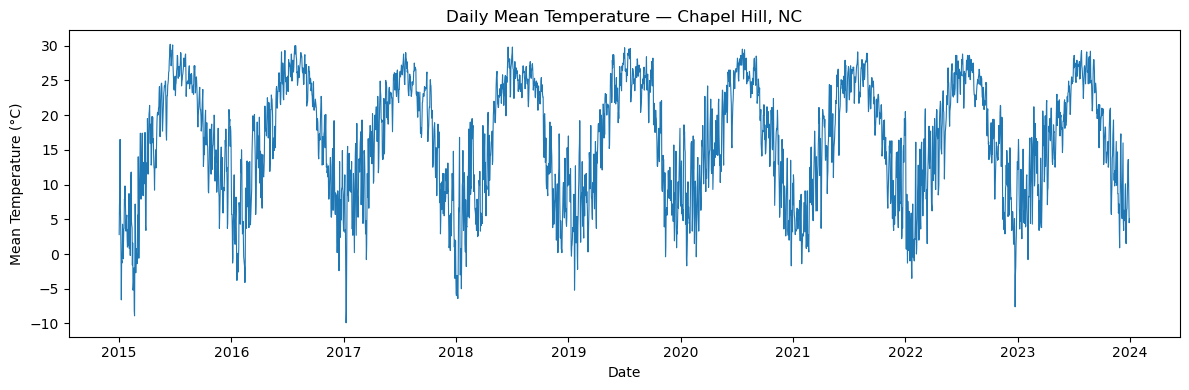

In [26]:
# Plot the real temperature history. Notice the clear yearly (seasonal) cycle.
plt.figure(figsize=(12, 4))
plt.plot(weather["date"], weather["temperature"], linewidth=0.8)
plt.xlabel("Date")
plt.ylabel("Mean Temperature (°C)")
plt.title("Daily Mean Temperature — Chapel Hill, NC")
plt.tight_layout()
plt.show()

### Step 2–3: Turn the time series into a supervised learning problem

An RNN learns by example: "given this input, predict this output." But a raw temperature series is just one long list of numbers — there are no input/output pairs yet. We create them with a **sliding window**.

The idea: walk a fixed-size window across the series. Everything *inside* the window is the input; the *very next* value is the target.

```
days:      [d0  d1  d2 ... d29] d30  d31 ...
window 1:  └──── input (30) ───┘  ↑ target
window 2:      └──── input (30) ──┘   ↑ target
window 3:          └──── input ───────┘  ...
```

So with a window of 30, the model learns to predict day 31's temperature from the previous 30 days, then slides forward one day and repeats. We also:

- **Scale** the temperatures to `[0, 1]` with `MinMaxScaler`. Neural networks train far more reliably when inputs are on a small, consistent range.
- **Split without shuffling** (`shuffle=False`). With time series we must train on the *past* and test on the *future* — shuffling would let the model "peek" at future data and give a misleadingly good score.

In [27]:
# 2. Scale the temperatures to the range [0, 1].
scaler = MinMaxScaler(feature_range=(0, 1))
temperature_scaled = scaler.fit_transform(temperature.reshape(-1, 1))

# 3. Slide a window over the series to build (input, target) pairs.
#    X[i] = 30 consecutive days, y[i] = the temperature on the very next day.
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])   # the past `seq_length` days
        y.append(data[i + seq_length])     # the next day (what we predict)
    return np.array(X), np.array(y)

seq_length = 30  # use the past 30 days to predict the next day
X, y = create_sequences(temperature_scaled, seq_length)

In [28]:
# Let's inspect what the windowing actually produced.
print("X shape:", X.shape, " ->  (num_windows, days_per_window, features)")
print("y shape:", y.shape, " ->  (num_windows, 1)")

# The first training example: 30 consecutive scaled temperatures...
print("\nFirst input window (30 scaled daily temps):")
print(np.round(X[0].ravel(), 3))

# ...and its target is the scaled temperature on the very next day.
print("\nTarget for that window (day 31):", round(float(y[0]), 3))

X shape: (3257, 30, 1)  ->  (num_windows, days_per_window, features)
y shape: (3257, 1)  ->  (num_windows, 1)

First input window (30 scaled daily temps):
[0.317 0.426 0.449 0.658 0.411 0.347 0.247 0.082 0.224 0.214 0.264 0.354
 0.319 0.229 0.279 0.337 0.339 0.444 0.436 0.491 0.449 0.399 0.329 0.352
 0.379 0.387 0.302 0.272 0.292 0.334]

Target for that window (day 31): 0.277


/var/folders/17/dbz231l146z3z6b3skmdsj0c0000gn/T/ipykernel_42135/4155939949.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("\nTarget for that window (day 31):", round(float(y[0]), 3))


In [29]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2605, 30, 1)
y_train shape: (2605, 1)


### Step 4: Build and train the RNN

The model is deliberately small: a single `SimpleRNN` layer (50 units) reads the 30-day window, and a `Dense(1)` layer outputs a single number — the predicted temperature for the next day. Because we're predicting a continuous value (not a category), we use **mean squared error (MSE)** as the loss instead of cross-entropy.

In [30]:
# 3. Build the RNN model using Keras
model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(seq_length, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.summary()

/opt/anaconda3/envs/Teaching-TensorFlow/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 4. Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0149 - val_loss: 0.0109
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0084 - val_loss: 0.0092
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0078 - val_loss: 0.0076
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0065 - val_loss: 0.0069
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0058 - val_loss: 0.0062
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0055 - val_loss: 0.0060
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0054 - val_loss: 0.0058
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0053 - val_loss: 0.0061
Epoch 9/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 - val_loss: 0.0064
Epoch 10/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0052 - val_loss: 0.0055
Epoch 11/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0048 - val_loss: 0.0056
Epoch 12/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0050 - val_lo

### Step 5: Evaluate on the held-out (future) data

Now we ask the model to predict temperatures for the test period — dates it never saw during training — and plot its predictions against what actually happened. We use `scaler.inverse_transform` to convert the `[0, 1]` predictions back into real degrees Celsius so the plot is interpretable. A good model's predicted curve should track the actual curve closely, especially the seasonal ups and downs.

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


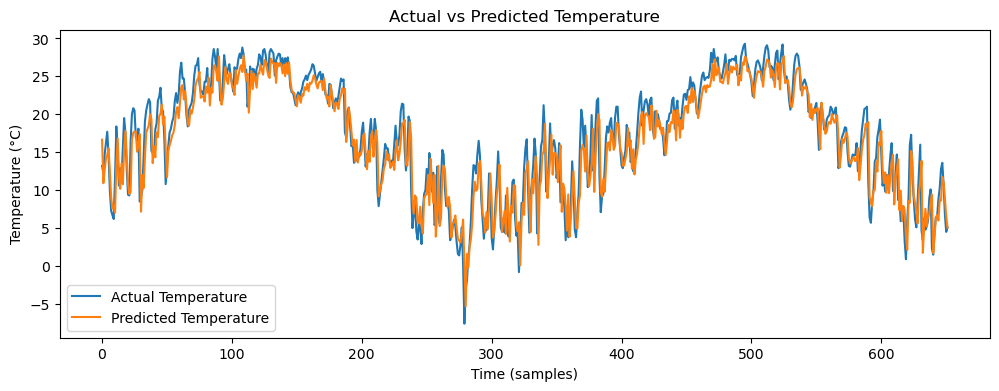

In [32]:
# 5. Evaluate the model and make predictions
predictions = model.predict(X_test)
predictions_inv = scaler.inverse_transform(predictions)
y_test_inv = scaler.inverse_transform(y_test)

# Plot the predictions vs actual temperatures
plt.figure(figsize=(12, 4))
plt.plot(y_test_inv, label='Actual Temperature')
plt.plot(predictions_inv, label='Predicted Temperature')
plt.xlabel("Time (samples)")
plt.ylabel("Temperature (°C)")
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.show()

### Step 6: Forecast the future (auto-regressive prediction)

Evaluation above is "one step at a time": each prediction uses 30 days of **real** data. But what if we want to forecast many days into the future, where we *don't* have real data yet?

We do it **auto-regressively** — the same idea behind text generation earlier in this notebook. We predict tomorrow, then *append our own prediction* to the window and use it to predict the day after, and so on. Each new prediction is built on top of previous predictions.

⚠️ **A caution:** because the model is now feeding on its own output, small errors compound over time. Auto-regressive forecasts are usually trustworthy for a short horizon and drift further from reality the longer you extrapolate — a real-world limitation worth seeing firsthand.

In [33]:
# 6. Generate future forecasts (auto-regressive prediction)
def forecast_future(model, last_sequence, num_forecast):
    forecast = []
    current_seq = last_sequence.copy()
    for _ in range(num_forecast):
        # Predict the next temperature
        next_val = model.predict(current_seq[np.newaxis, :, :])
        forecast.append(next_val[0, 0])
        # Append the predicted value and remove the first value of the sequence
        current_seq = np.append(current_seq[1:], [[next_val[0, 0]]], axis=0)
    return np.array(forecast)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

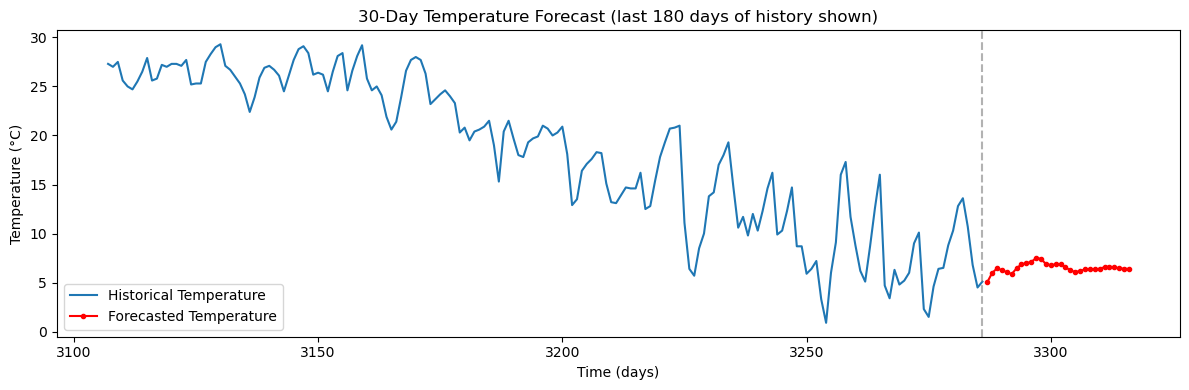

In [34]:
# Use the last available window to forecast the next 30 days.
last_seq = X_test[-1]
future_steps = 30  # forecast next 30 days
forecast_scaled = forecast_future(model, last_seq, future_steps)
forecast = scaler.inverse_transform(forecast_scaled.reshape(-1, 1))

# Zoom in on the most recent history so the short forecast is visible.
history_tail = 180
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(temperature) - history_tail, len(temperature)),
         temperature[-history_tail:], label="Historical Temperature")
plt.plot(np.arange(len(temperature), len(temperature) + future_steps),
         forecast, label="Forecasted Temperature", color='red', marker='.')
plt.axvline(len(temperature) - 1, color='gray', linestyle='--', alpha=0.6)
plt.xlabel("Time (days)")
plt.ylabel("Temperature (°C)")
plt.title("30-Day Temperature Forecast (last 180 days of history shown)")
plt.legend()
plt.tight_layout()
plt.show()